In [2]:
%pip install numpy metpy sounderpy
%pip install beautifulsoup4 bs4
%pip install cppimport


  Using cached metpy-1.7.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached cdsapi-0.7.7-py2.py3-none-any.whl.metadata (3.1 kB)
  Using cached ecape_parcel-1.2.2-py3-none-any.whl.metadata (12 kB)
INFO: pip is looking at multiple versions of sounderpy to determine which version is compatible with other requirements. This could take a while.
  Using cached sounderpy-3.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached fsspec-2026.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached open_radar_data-0.8.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached s3fs-2026.9.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached pyshp-3.1.6-py3-none-any.whl.metadata (79 kB)
  Using cached ecmwf_datastores_client-0.5.3-py3-none-any.whl.metadata (8.7 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached ecape-0.1.1-py3-none-any.whl.metadata (3.6 kB)

In [1]:
from src import sounderpy as spy_modified
import sounderpy as spy
import pandas as pd
import numpy as np
from metpy.units import units
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import metpy.calc as mpcalc
import metpy.interpolate as mpinterp
from metpy.plots import Hodograph, SkewT

c:\Users\danie\anaconda3\envs\sounding_variable_calc_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## ---------------------------------- SOUNDERPY ----------------------------------- ##
##          Vertical Profile Data Retrieval and Analysis Tool For Python            ##
##                   v3.1.0 | October 2025 | (C) Kyle J Gillett                     ##
##                 Docs: https://kylejgillett.github.io/sounderpy/                  ##
## --------------------- THANK YOU FOR USING THIS PACKAGE! ------------------------ ##



In [4]:
def makeSounding(f):
  data = pd.read_csv(f, delimiter=' ', names=['p (hPa)', 'T (C)', 'Td (C)', 'RH (%)', 'u (m/s)', 'v (m/s)', 'h (m)'])
  metadata = f.split("_")
  #Start with empty dictionary
  clean_data = {}

  #Meteorological Data
  clean_data['p']  = np.array(data['p (hPa)']) * units.hPa
  clean_data['z']  = np.array(data['h (m)'])*units.m
  clean_data['T']  = np.array(data['T (C)'])*units.degC
  clean_data['Td'] = np.array(data['Td (C)'])*units.degC
  clean_data['u']  = np.array(data['u (m/s)'])*units('m/s')
  clean_data['v']  = np.array(data['v (m/s)'])*units('m/s')

  # Metadata
  clean_data['site_info'] = {
              'site-id'     : "Template",
              'site-name'   : "Template",
              'site-lctn'   : "Template",
              'site-latlon' : [float(0), float(0)],
              'site-elv'    : -1,                  #Placeholder value as shouldn't be needed
              'source'      : 'Data',
              'model'       : 'none',
              'fcst-hour'   : f'none',
              'run-time'    : ['none', 'none', 'none', 'none'],
              'valid-time'  : ["00", "00", "00", "00" + ":00"]}      # the profile's valid date/time.

  clean_data['titles'] = {
              'top_title': 'PLACEHOLDER | PLACEHOLDER',
              'left_title': 'VALID: PLACEHOLDER - PLACEHOLDER',
              'right_title': 'PLACEHOLDER, PLACEHOLDER [PLACEHOLDER, PLACEHOLDER]    '}

  spy.build_sounding(clean_data)

In [2]:
def makeSoundingModified(f):
  data = pd.read_csv(f, delimiter=' ', names=['p (hPa)', 'T (C)', 'Td (C)', 'RH (%)', 'u (m/s)', 'v (m/s)', 'h (m)'])
  metadata = f.split("_")
  #Start with empty dictionary
  clean_data = {}

  #Meteorological Data
  clean_data['p']  = np.array(data['p (hPa)']) * units.hPa
  clean_data['z']  = np.array(data['h (m)'])*units.m
  clean_data['T']  = np.array(data['T (C)'])*units.degC
  clean_data['Td'] = np.array(data['Td (C)'])*units.degC
  clean_data['u']  = np.array(data['u (m/s)'])*units('m/s')
  clean_data['v']  = np.array(data['v (m/s)'])*units('m/s')

  # Metadata
  clean_data['site_info'] = {
              'site-id'     : "Template",
              'site-name'   : "Template",
              'site-lctn'   : "Template",
              'site-latlon' : [float(0), float(0)],
              'site-elv'    : -1,                  #Placeholder value as shouldn't be needed
              'source'      : 'Data',
              'model'       : 'none',
              'fcst-hour'   : f'none',
              'run-time'    : ['none', 'none', 'none', 'none'],
              'valid-time'  : ["00", "00", "00", "00" + ":00"]}      # the profile's valid date/time.

  clean_data['titles'] = {
              'top_title': 'PLACEHOLDER | PLACEHOLDER',
              'left_title': 'VALID: PLACEHOLDER - PLACEHOLDER',
              'right_title': 'PLACEHOLDER, PLACEHOLDER [PLACEHOLDER, PLACEHOLDER]    '}

  spy_modified.build_sounding(clean_data)

> SOUNDING PLOTTER FUNCTION
  ---------------------------------


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


    > COMPLETE --------
    > RUNTIME: 00:00:08


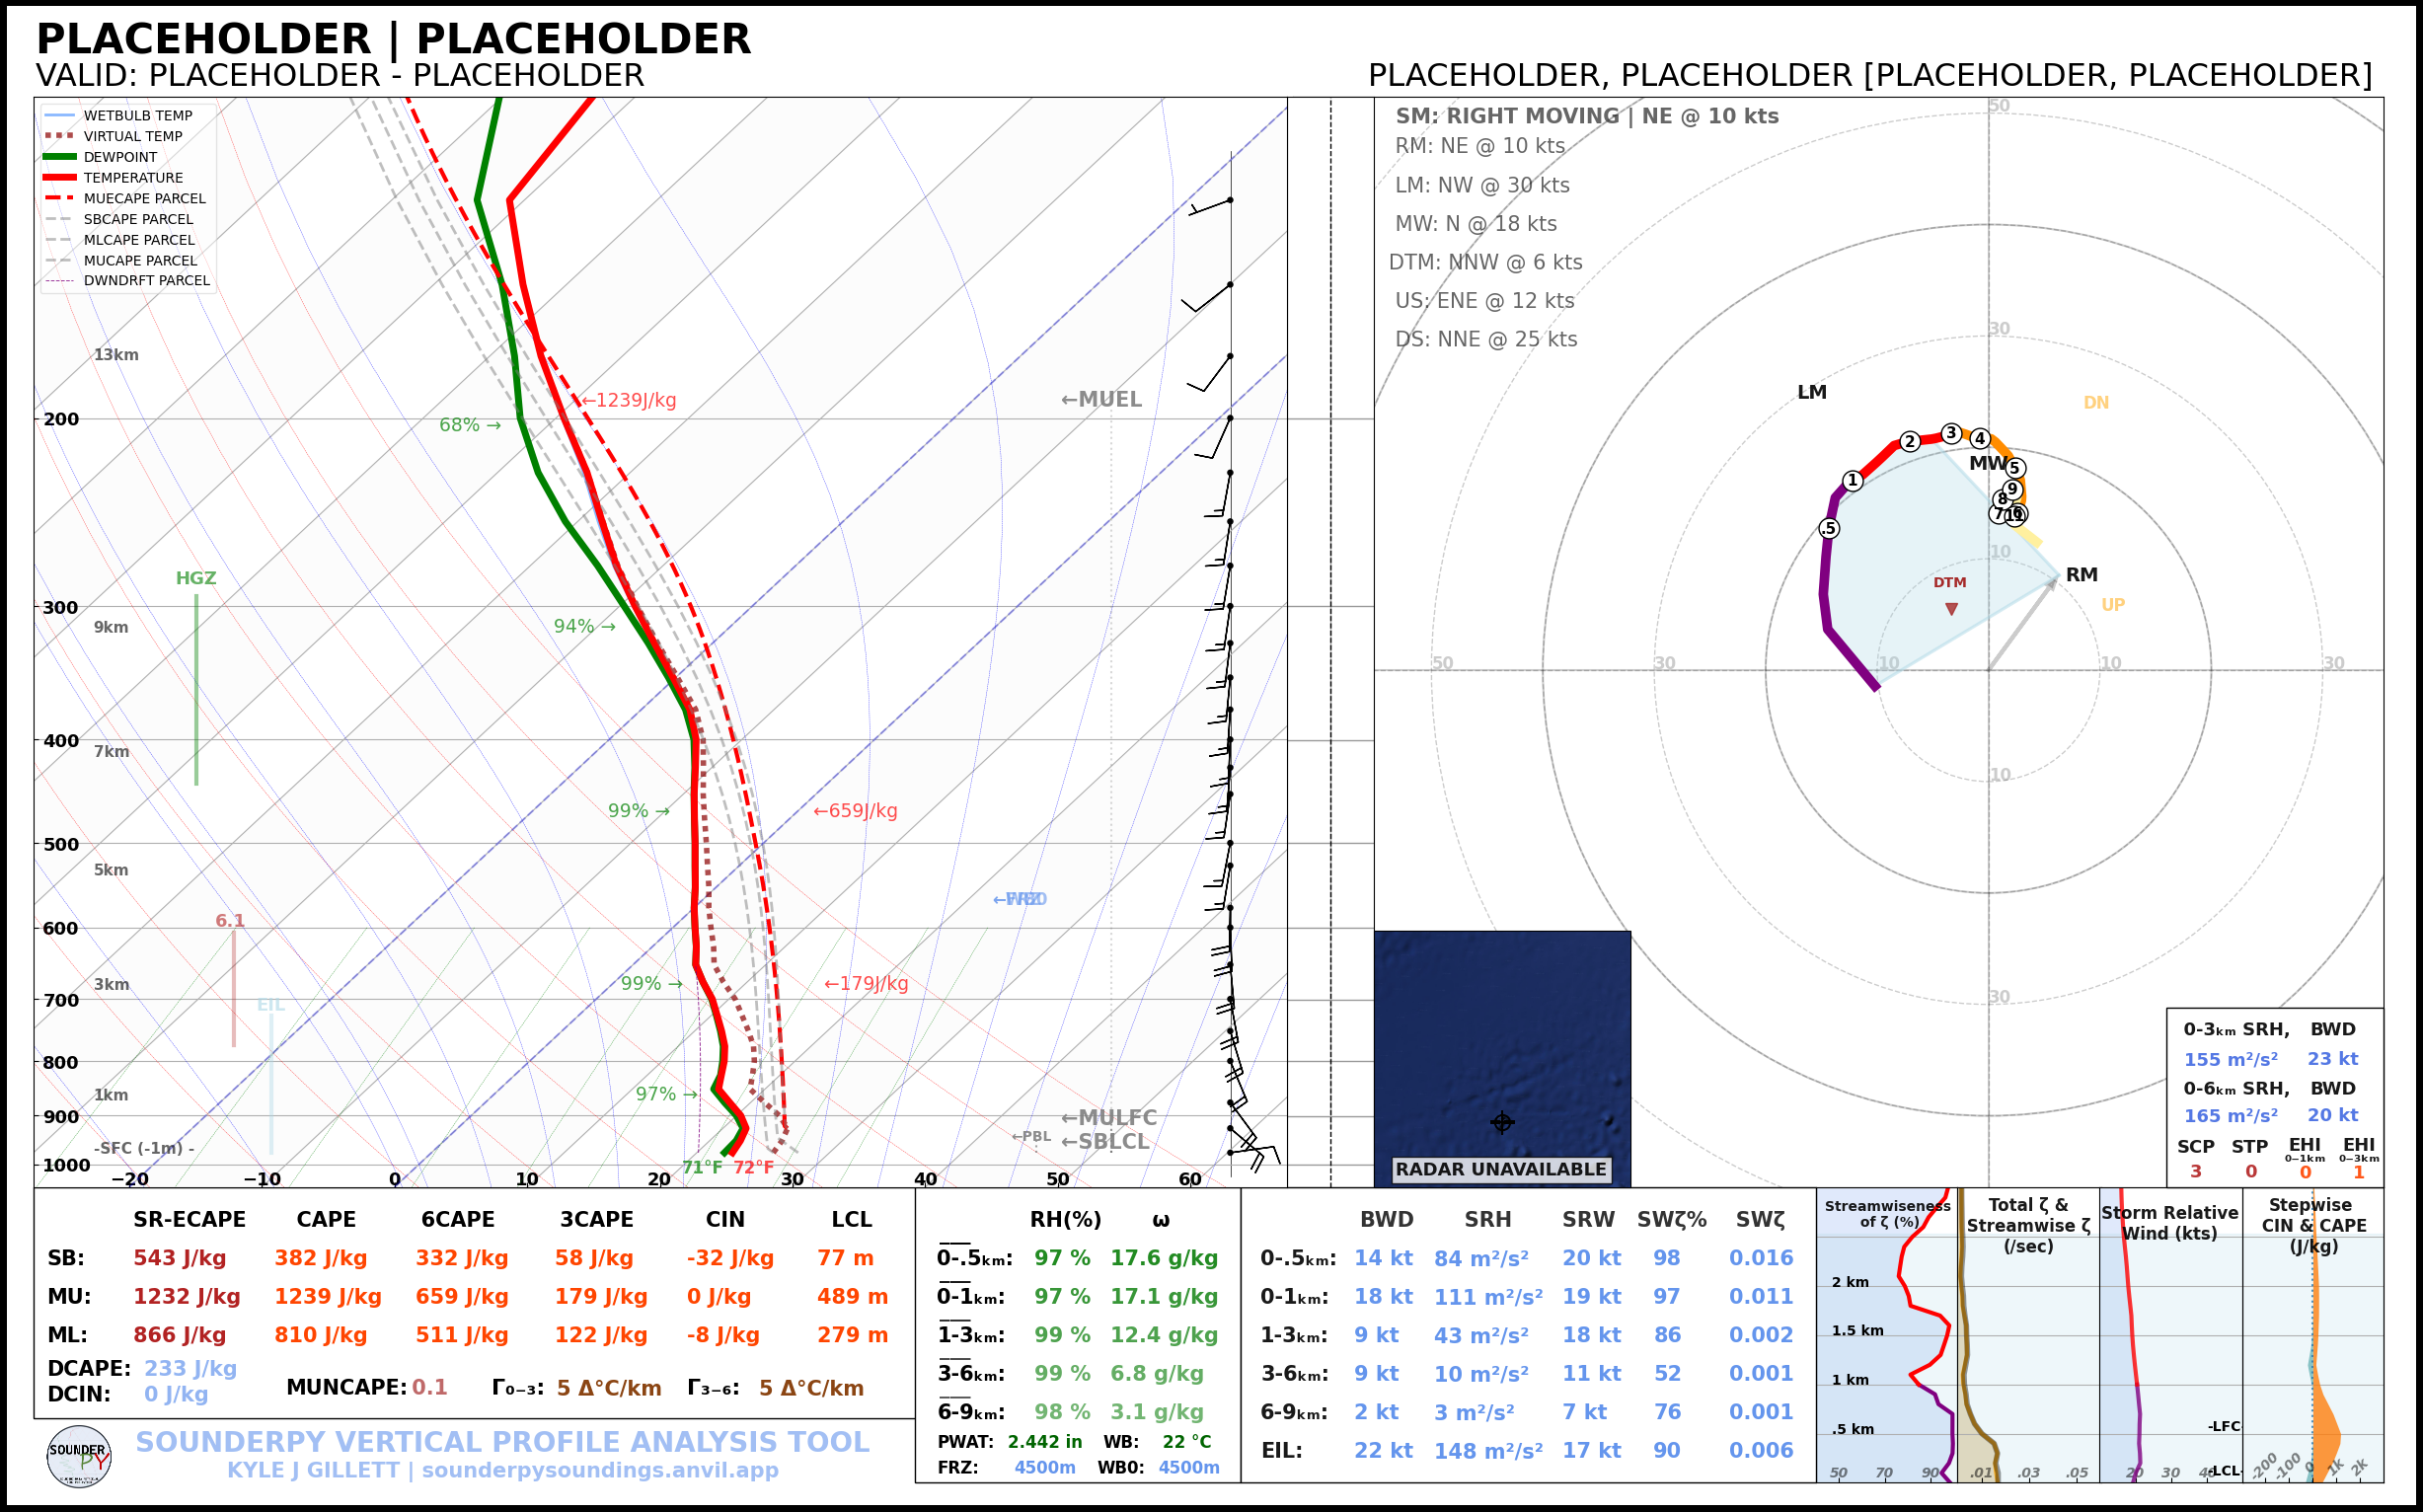

In [6]:
makeSounding('example')

> SOUNDING PLOTTER FUNCTION
  ---------------------------------
    > PREPARING DATA
    > BUILDING SKEW-T LOG-P DIAGRAM
    > BUILDING HODOGRAPH
    > BUILDING MAP INSET
    > BUILDING ACCESSORY PLOTS
    > PLOTTING SOUNDING PARAMETERS
    > FIGURE LOADING...
    > COMPLETE --------
    > RUNTIME: 00:00:08


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


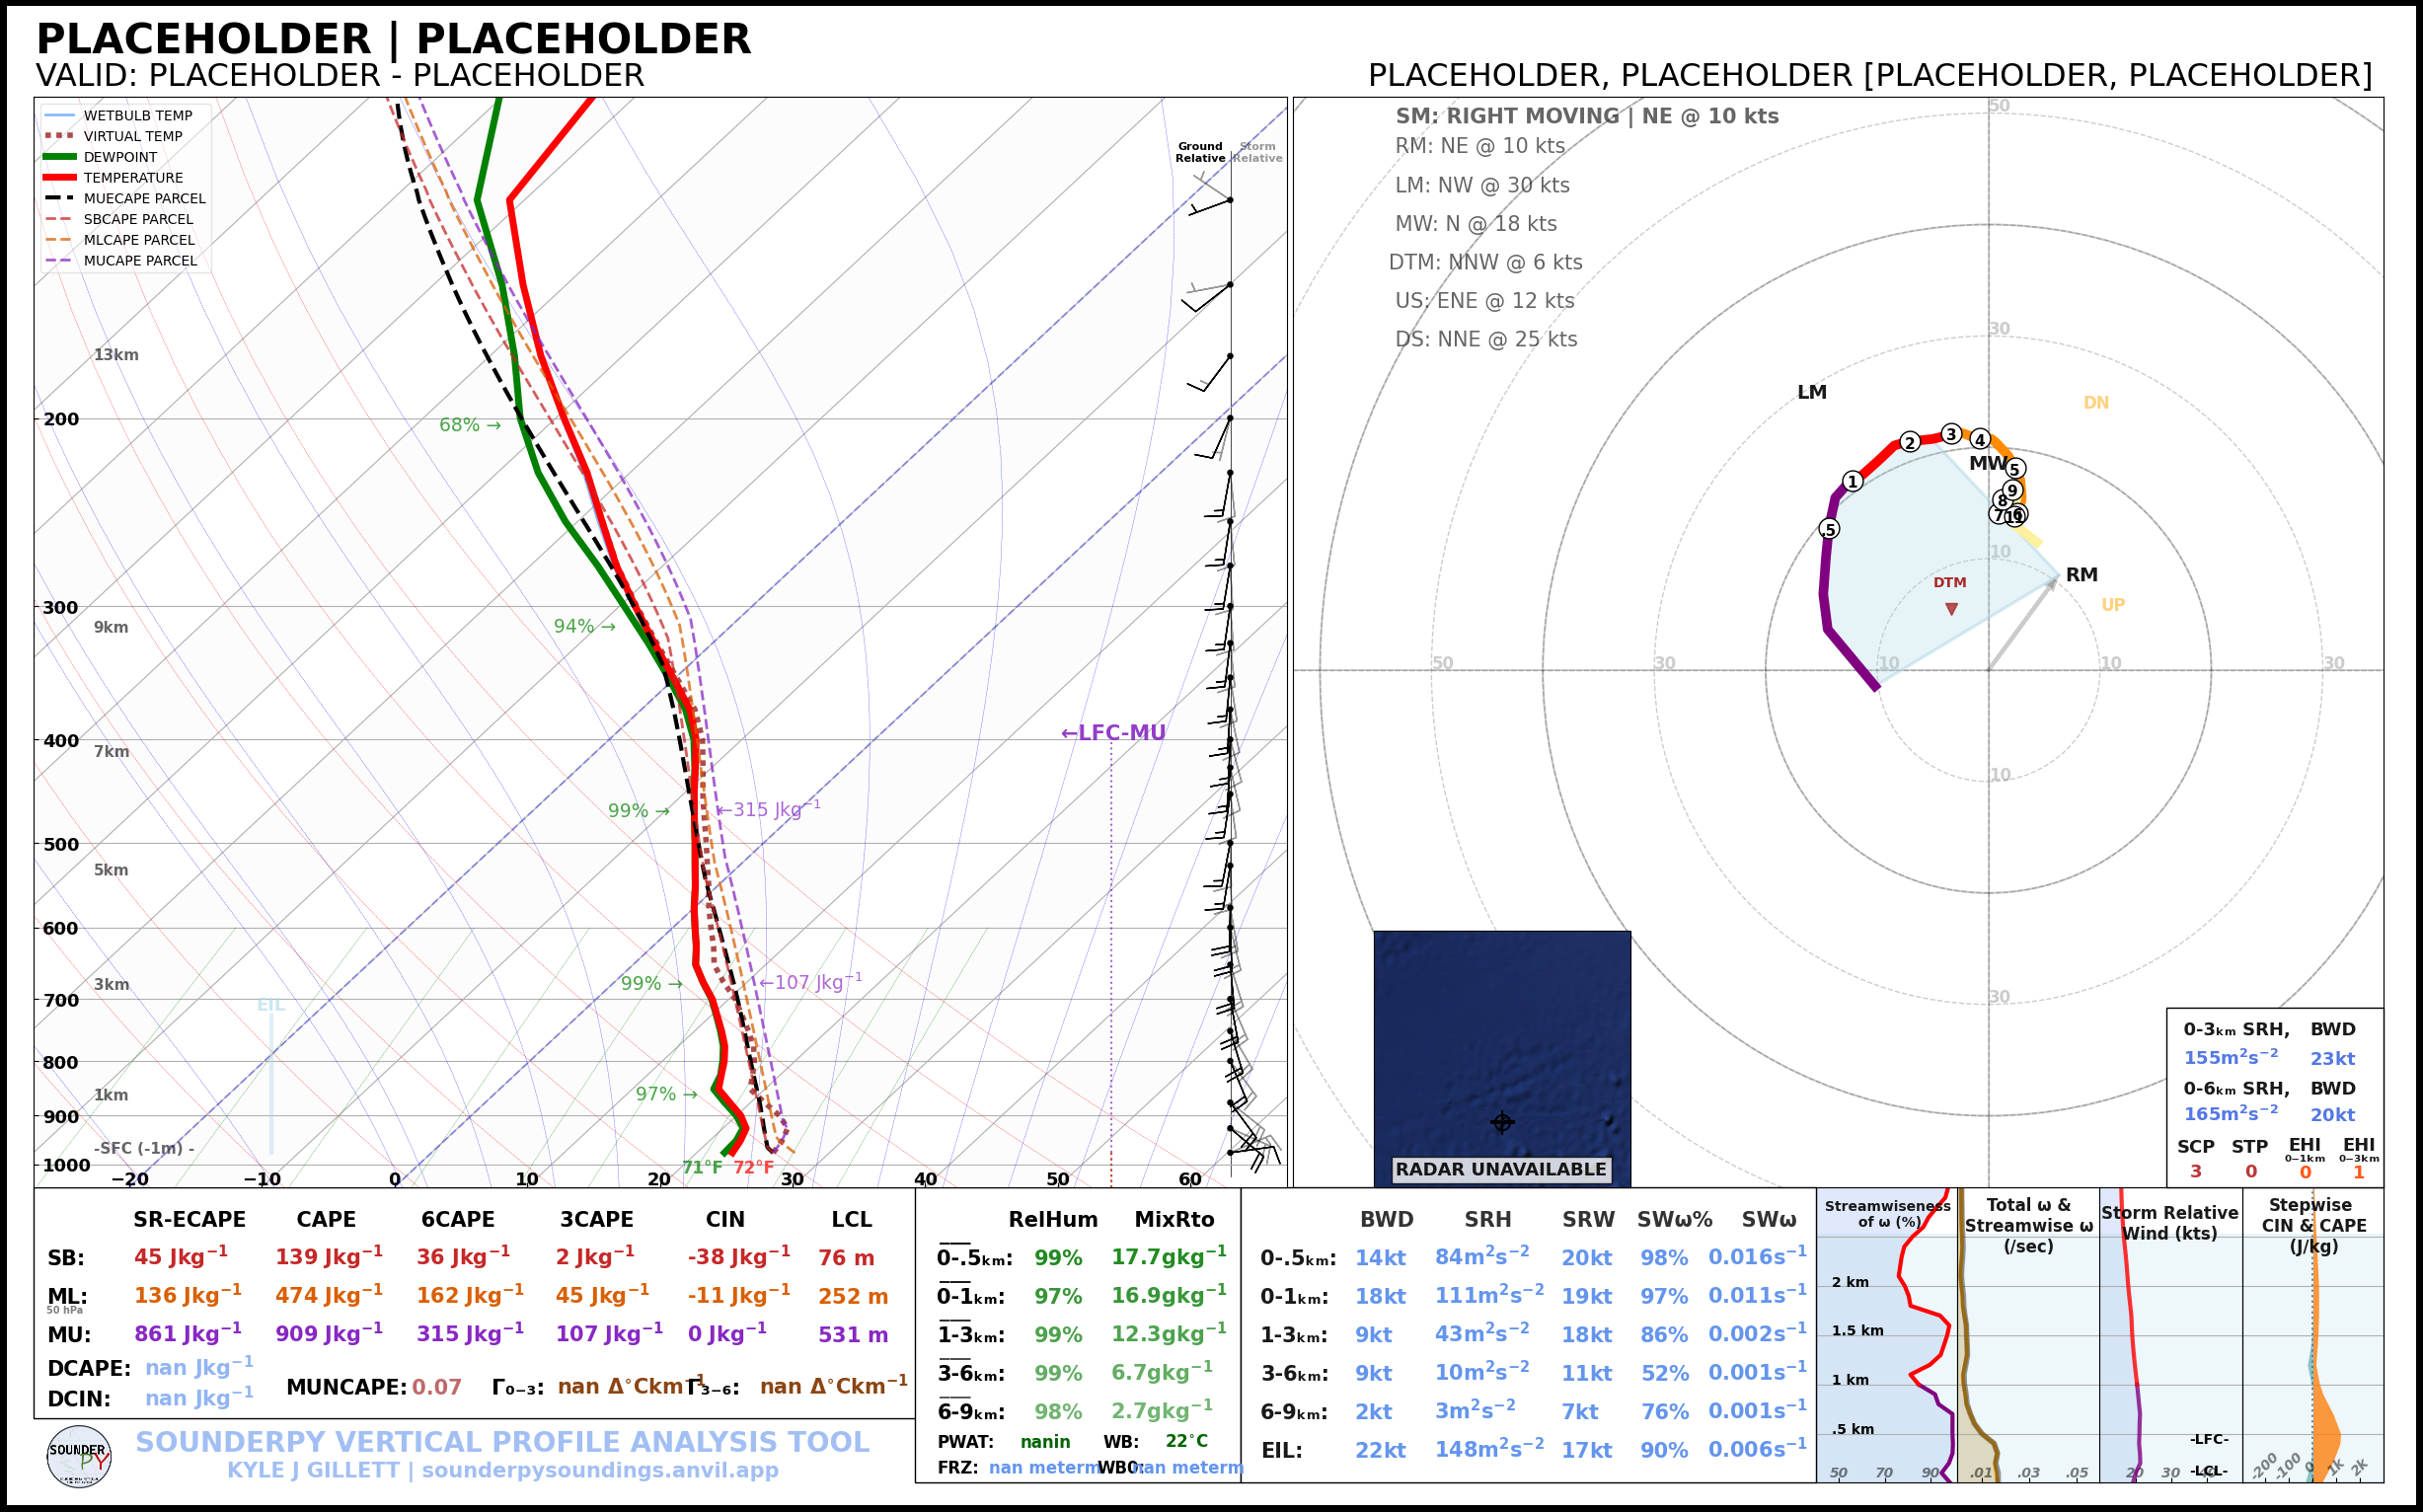

In [3]:
makeSoundingModified('example')